<a href="https://colab.research.google.com/github/hussein-alnaffakh1984/-/blob/main/CANCER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 0) Setup (Colab)
# =========================
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install scikit-learn pandas tqdm matplotlib

import os, random, math, time
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [ ]:
import os, subprocess, textwrap, sys

print("exists /content/drive ?", os.path.exists("/content/drive"))
if os.path.exists("/content/drive"):
    print("Listing /content/drive:")
    !ls -la /content/drive | head


exists /content/drive ? False


In [ ]:
import os

# إذا MyDrive موجود -> Drive مربوط بالفعل
if os.path.exists("/content/drive/MyDrive"):
    print("✅ Google Drive already mounted.")
else:
    from google.colab import drive
    drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"
print("DATA_DIR exists?", os.path.isdir(DATA_DIR))
if os.path.isdir(DATA_DIR):
    print("Folders:", os.listdir(DATA_DIR))


Mounted at /content/drive
DATA_DIR exists? True
Folders: ['.DS_Store', 'blast', 'normal']


In [ ]:
!ls -la "/content/drive/MyDrive/C-NMC_training_data" | head
!ls -la "/content/drive/MyDrive/C-NMC_training_data/blast" | head
!ls -la "/content/drive/MyDrive/C-NMC_training_data/normal" | head


total 15
drwx------ 2 root root 4096 Jan 19 22:35 blast
-rw------- 1 root root 6148 Jan 19 18:08 .DS_Store
drwx------ 2 root root 4096 Jan 19 22:35 normal
total 4323204
-rw------- 1 root root 608454 Jan 19 18:49 UID_1_10_1_all.bmp
-rw------- 1 root root 608454 Jan 19 18:49 UID_1_10_2_all.bmp
-rw------- 1 root root 608454 Jan 19 18:49 UID_1_10_3_all.bmp
-rw------- 1 root root 608454 Jan 19 18:49 UID_1_10_4_all.bmp
-rw------- 1 root root 608454 Jan 19 18:48 UID_11_10_1_all.bmp
-rw------- 1 root root 608454 Jan 19 18:48 UID_11_11_1_all.bmp
-rw------- 1 root root 608454 Jan 19 18:48 UID_11_11_2_all.bmp
-rw------- 1 root root 608454 Jan 19 18:48 UID_11_11_3_all.bmp
-rw------- 1 root root 608454 Jan 19 18:49 UID_1_11_1_all.bmp
total 2014761
-rw------- 1 root root 608454 Jan 19 18:24 UID_H10_100_1_hem.bmp
-rw------- 1 root root 608454 Jan 19 18:24 UID_H10_100_2_hem.bmp
-rw------- 1 root root 608454 Jan 19 18:24 UID_H10_100_3_hem.bmp
-rw------- 1 root root 608454 Jan 19 18:24 UID_H10_100_4_hem

In [ ]:
!ls -la "/content/drive/MyDrive" | head -n 50


total 1442912
-rw------- 1 root root   1653683 Sep  6 10:35 2101 (1).pdf
-rw------- 1 root root   1656536 Sep  6 10:56 2101.pdf
-rw------- 1 root root    186873 Dec 24 20:11 (2+4)خرائط النهائي الفصل الاول.xlsx
-rw------- 1 root root   2288846 Sep  6 10:57 2660.pdf
-rw------- 1 root root   2061581 Sep  6 10:36 2747 (1).pdf
-rw------- 1 root root   2066229 Sep  6 10:56 2747.pdf
-rw------- 1 root root     41709 Nov 21 07:35 3.2.drawio
-rw------- 1 root root   3169209 Dec 15 13:51 3478-Article Text-23003-1-2-20251215.docx.pdf
-rw------- 1 root root    318594 Jan 18  2024 3604-8305-1-PB.pdf
-rw------- 1 root root     21529 Aug 15 15:39 4.1.drawio
-rw------- 1 root root        85 Aug 13 18:45 4.drawio
-rw------- 1 root root      5865 Nov 25 11:44 Adaptive Post-Processing (APP).drawio
-rw------- 1 root root     70630 Nov 21 08:29 AH-U-Net Architecture.drawio
-rw------- 1 root root     88876 Aug  2 18:44 AH-U-Net Architecture.jpg
-rw------- 1 root root 376792016 Jul 28 01:15 AH_U_Net_EdgeBCE

In [ ]:
# =========================
# 1) Mount Google Drive (SAFE)
# =========================
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount('/content/drive', force_remount=True)
else:
    print("✅ Google Drive already mounted")

# =========================
# 2) Dataset path
# =========================
DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"

assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"
print("Found DATA_DIR:", DATA_DIR)
print("Folders:", os.listdir(DATA_DIR))


✅ Google Drive already mounted
Found DATA_DIR: /content/drive/MyDrive/C-NMC_training_data
Folders: ['.DS_Store', 'blast', 'normal']


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os

if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("✅ Google Drive already mounted")


✅ Google Drive already mounted


In [ ]:
# =========================
# 1) Mount Google Drive
# =========================
from google.colab import drive
import os

drive.mount('/content/drive')

# ✅ المسار الصحيح حسب ما رفعتَه
DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"

# الهيكل الصحيح:
# DATA_DIR/
#   normal/
#     UID_..._hem.bmp
#   blast/
#     UID_..._all.bmp

assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"
print("Found DATA_DIR:", DATA_DIR)
print("Folders:", os.listdir(DATA_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found DATA_DIR: /content/drive/MyDrive/C-NMC_training_data
Folders: ['.DS_Store', 'blast', 'normal']


In [ ]:
import os, glob

DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"

normal_dir = os.path.join(DATA_DIR, "normal")
blast_dir  = os.path.join(DATA_DIR, "blast")

normal_imgs = glob.glob(os.path.join(normal_dir, "*.bmp"))
blast_imgs  = glob.glob(os.path.join(blast_dir, "*.bmp"))

print("Normal images:", len(normal_imgs))
print("Blast  images:", len(blast_imgs))

# اعرض 3 أسماء للتأكد
print("\nSample Normal:", [os.path.basename(p) for p in normal_imgs[:3]])
print("Sample Blast :", [os.path.basename(p) for p in blast_imgs[:3]])

assert len(normal_imgs) > 0 and len(blast_imgs) > 0, "No images found! Check folders."


Normal images: 3389
Blast  images: 7272

Sample Normal: ['UID_H12_28_2_hem.bmp', 'UID_H12_25_5_hem.bmp', 'UID_H12_25_9_hem.bmp']
Sample Blast : ['UID_48_27_1_all.bmp', 'UID_48_28_11_all.bmp', 'UID_48_26_7_all.bmp']


Opened: UID_H8_4_2_hem.bmp Mode: RGB Size: (450, 450)


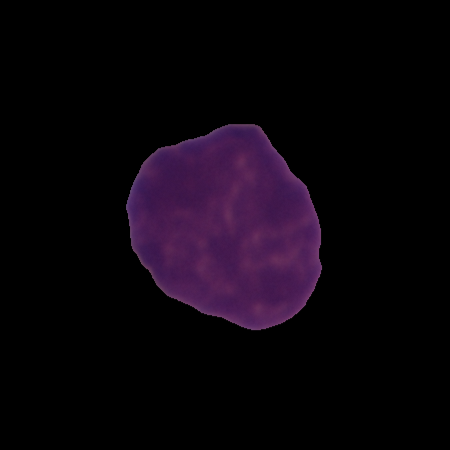

In [ ]:
from PIL import Image
import random

# اختر صورة عشوائية من normal
p = random.choice(normal_imgs)
img = Image.open(p)
print("Opened:", os.path.basename(p), "Mode:", img.mode, "Size:", img.size)
img


In [ ]:
import os, torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"

# 1) Transforms (مبدئيًا)
IMG_SIZE = 224
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 2) Dataset (ImageFolder يعتمد على أسماء المجلدات)
full_ds = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
print("Classes:", full_ds.classes)
print("Class->idx:", full_ds.class_to_idx)
print("Total samples:", len(full_ds))

# 3) Split indices (Stratified)
targets = [y for _, y in full_ds.samples]
idx = list(range(len(full_ds)))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, random_state=42, stratify=targets
)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=temp_targets
)

print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))

# 4) Subsets
train_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=train_tfms), train_idx)
val_ds   = Subset(datasets.ImageFolder(DATA_DIR, transform=val_tfms), val_idx)
test_ds  = Subset(datasets.ImageFolder(DATA_DIR, transform=val_tfms), test_idx)

# 5) DataLoaders
BATCH_SIZE = 32
num_workers = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

# 6) اختبار Batch واحد
x, y = next(iter(train_loader))
print("Batch x:", x.shape, "Batch y:", y.shape)
print("y unique in batch:", torch.unique(y))


Classes: ['blast', 'normal']
Class->idx: {'blast': 0, 'normal': 1}
Total samples: 10661
Train: 7462 Val: 1599 Test: 1600
Batch x: torch.Size([32, 3, 224, 224]) Batch y: torch.Size([32])
y unique in batch: tensor([0, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# 1) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2) Model (Baseline)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)  # binary classes
model = model.to(device)

# 3) Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 4) Train 1 epoch (sanity check)
model.train()
train_loss, train_correct, train_total = 0.0, 0, 0

for x, y in tqdm(train_loader, desc="Train (1 epoch)"):
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    train_loss += loss.item() * x.size(0)
    preds = logits.argmax(dim=1)
    train_correct += (preds == y).sum().item()
    train_total += y.size(0)

train_loss /= train_total
train_acc = train_correct / train_total
print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

# 5) Quick Validation
model.eval()
val_loss, val_correct, val_total = 0.0, 0, 0

with torch.no_grad():
    for x, y in tqdm(val_loader, desc="Val"):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        val_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        val_correct += (preds == y).sum().item()
        val_total += y.size(0)

val_loss /= val_total
val_acc = val_correct / val_total
print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Device: cuda


Train (1 epoch): 100%|██████████| 234/234 [22:17<00:00,  5.72s/it]


Train Loss: 0.3309 | Train Acc: 0.8668


Val: 100%|██████████| 50/50 [04:27<00:00,  5.35s/it]

Val Loss: 0.3527 | Val Acc: 0.8655


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# Multi-Head Model
# -------------------------
class DecisionNet(nn.Module):
    def __init__(self, num_classes=2, num_actions=3):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.cls_head = nn.Linear(feat_dim, num_classes)   # blast/normal
        self.act_head = nn.Linear(feat_dim, num_actions)   # accept/review/defer

    def forward(self, x):
        f = self.backbone(x)
        cls_logits = self.cls_head(f)
        act_logits = self.act_head(f)
        return cls_logits, act_logits

model = DecisionNet(num_classes=2, num_actions=3).to(device)

# -------------------------
# Risk-aware settings
# -------------------------
ACCEPT, REVIEW, DEFER = 0, 1, 2

lambda_review = 0.15   # cost for "review"
lambda_defer  = 0.30   # cost for "defer"
alpha_fn = 2.0         # extra penalty for missing BLAST (false negative risk)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Weighted CE to penalize FN (blast is class 0)
# targets: blast=0, normal=1
w = torch.tensor([alpha_fn, 1.0], device=device)
cls_criterion = nn.CrossEntropyLoss(weight=w)

def decision_loss(cls_logits, act_logits, y_true):
    """
    y_true: [B] with {0: blast, 1: normal}
    act: {0: accept, 1: review, 2: defer}
    """
    B = y_true.size(0)
    act_probs = F.softmax(act_logits, dim=1)          # [B,3]
    p_accept = act_probs[:, ACCEPT]
    p_review = act_probs[:, REVIEW]
    p_defer  = act_probs[:, DEFER]

    # classification loss (per-sample)
    per_sample_ce = F.cross_entropy(cls_logits, y_true, weight=w, reduction="none")  # [B]

    # expected loss:
    # - if accept -> pay classification loss
    # - if review/defer -> pay their costs (encourage accept when safe)
    exp_loss = (p_accept * per_sample_ce) + (p_review * lambda_review) + (p_defer * lambda_defer)

    # regularize: prevent degenerate always-defer
    # encourage some accept mass on average
    accept_reg = (0.6 - p_accept.mean()).clamp(min=0)  # if mean accept < 0.6, penalty
    reg = 0.10 * accept_reg

    return exp_loss.mean() + reg

# -------------------------
# Train 1 epoch (sanity)
# -------------------------
def run_epoch(train=True):
    model.train() if train else model.eval()
    loader = train_loader if train else val_loader

    total_loss, n = 0.0, 0

    # decision metrics
    accept_count = 0
    correct_on_accept = 0
    total_accept = 0

    with torch.set_grad_enabled(train):
        for x, y in tqdm(loader, desc=("Train Decision" if train else "Val Decision")):
            x, y = x.to(device), y.to(device)

            cls_logits, act_logits = model(x)
            loss = decision_loss(cls_logits, act_logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

            # Compute acceptance + accuracy on accepted
            act = act_logits.argmax(dim=1)  # hard decision for monitoring
            accept_mask = (act == ACCEPT)
            total_accept += accept_mask.sum().item()

            if accept_mask.any():
                preds = cls_logits.argmax(dim=1)
                correct_on_accept += (preds[accept_mask] == y[accept_mask]).sum().item()

    avg_loss = total_loss / n
    coverage = total_accept / n
    acc_accept = (correct_on_accept / total_accept) if total_accept > 0 else 0.0
    return avg_loss, coverage, acc_accept

train_loss, train_cov, train_acc_acc = run_epoch(train=True)
val_loss, val_cov, val_acc_acc = run_epoch(train=False)

print(f"\nTrain Loss: {train_loss:.4f} | Coverage(accept): {train_cov:.3f} | Acc@Accept: {train_acc_acc:.3f}")
print(f"Val   Loss: {val_loss:.4f} | Coverage(accept): {val_cov:.3f} | Acc@Accept: {val_acc_acc:.3f}")


Device: cuda


Val Decision: 100%|██████████| 50/50 [00:14<00:00,  3.41it/s]


Train Loss: 0.2195 | Coverage(accept): 0.018 | Acc@Accept: 0.925
Val   Loss: 0.2107 | Coverage(accept): 0.000 | Acc@Accept: 0.000


In [ ]:
import torch

ACCEPT, REVIEW, DEFER = 0, 1, 2

def action_distribution(loader, name=""):
    model.eval()
    counts = torch.zeros(3, dtype=torch.long)
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, act_logits = model(x)
            act = act_logits.argmax(dim=1).cpu()
            for k in [ACCEPT, REVIEW, DEFER]:
                counts[k] += (act == k).sum()
    total = counts.sum().item()
    print(f"{name} Action counts:", counts.tolist(), " Total:", total)
    print(f"{name} Action %: Accept={counts[0]/total:.3f}, Review={counts[1]/total:.3f}, Defer={counts[2]/total:.3f}")

action_distribution(train_loader, "Train")
action_distribution(val_loader, "Val")


Train Action counts: [0, 7462, 0]  Total: 7462
Train Action %: Accept=0.000, Review=1.000, Defer=0.000
Val Action counts: [0, 1599, 0]  Total: 1599
Val Action %: Accept=0.000, Review=1.000, Defer=0.000


In [ ]:
import torch.nn.functional as F

# اجعل الامتناع أغلى من التصنيف
lambda_review = 0.60
lambda_defer  = 1.00

# نجبر Coverage لا يقل عن حد أدنى (مثلاً 0.30 بالبداية)
min_coverage = 0.30
coverage_weight = 1.0

# تقوية قبول الحالات (بدل 0.6) + زيادة تأثير الـ reg
accept_target = 0.70
accept_reg_weight = 0.50

def decision_loss(cls_logits, act_logits, y_true):
    act_probs = F.softmax(act_logits, dim=1)
    p_accept = act_probs[:, 0]
    p_review = act_probs[:, 1]
    p_defer  = act_probs[:, 2]

    per_sample_ce = F.cross_entropy(cls_logits, y_true, weight=w, reduction="none")

    exp_loss = (p_accept * per_sample_ce) + (p_review * lambda_review) + (p_defer * lambda_defer)

    # Coverage penalty: إذا متوسط القبول أقل من min_coverage نعاقبه
    cov = p_accept.mean()
    cov_pen = coverage_weight * (min_coverage - cov).clamp(min=0)

    # Accept regularization: ادفعه باتجاه accept_target
    acc_reg = accept_reg_weight * (accept_target - cov).clamp(min=0)

    return exp_loss.mean() + cov_pen + acc_reg


In [ ]:
train_loss, train_cov, train_acc_acc = run_epoch(train=True)
val_loss, val_cov, val_acc_acc = run_epoch(train=False)

print(f"\nTrain Loss: {train_loss:.4f} | Coverage(accept): {train_cov:.3f} | Acc@Accept: {train_acc_acc:.3f}")
print(f"Val   Loss: {val_loss:.4f} | Coverage(accept): {val_cov:.3f} | Acc@Accept: {val_acc_acc:.3f}")


Val Decision: 100%|██████████| 50/50 [00:14<00:00,  3.48it/s]


Train Loss: 0.5441 | Coverage(accept): 0.638 | Acc@Accept: 0.880
Val   Loss: 0.4037 | Coverage(accept): 0.685 | Acc@Accept: 0.925


In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

ACCEPT, REVIEW, DEFER = 0, 1, 2

def evaluate_test(model, loader):
    model.eval()

    y_true_all = []
    y_pred_all = []
    y_prob_blast_all = []   # probability of class blast (0)
    act_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            cls_logits, act_logits = model(x)

            probs = torch.softmax(cls_logits, dim=1)          # [B,2]
            pred = cls_logits.argmax(dim=1)                   # [B]
            act  = act_logits.argmax(dim=1)                   # [B]

            y_true_all.append(y.cpu().numpy())
            y_pred_all.append(pred.cpu().numpy())
            y_prob_blast_all.append(probs[:, 0].cpu().numpy())  # blast prob
            act_all.append(act.cpu().numpy())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_prob_blast_all = np.concatenate(y_prob_blast_all)
    act_all = np.concatenate(act_all)

    # Coverage
    accept_mask = (act_all == ACCEPT)
    coverage = accept_mask.mean()

    # Metrics on accepted only
    if accept_mask.sum() > 0:
        y_true_acc = y_true_all[accept_mask]
        y_pred_acc = y_pred_all[accept_mask]
        y_prob_blast_acc = y_prob_blast_all[accept_mask]

        cm = confusion_matrix(y_true_acc, y_pred_acc, labels=[0,1])  # blast=0, normal=1
        report = classification_report(y_true_acc, y_pred_acc, target_names=["blast","normal"], digits=4)

        # AUC (blast vs normal) on accepted
        # y_true_acc: blast=0 -> we need binary label for blast=1
        y_blast_label = (y_true_acc == 0).astype(int)
        auc = roc_auc_score(y_blast_label, y_prob_blast_acc)

        # FN-focused metrics (missed blast among accepted)
        tn, fp, fn, tp = cm.ravel()
        sensitivity_blast = tp / (tp + fn + 1e-9)   # recall for blast
        fn_rate_blast = fn / (tp + fn + 1e-9)

    else:
        cm, report, auc, sensitivity_blast, fn_rate_blast = None, None, None, None, None

    # Action distribution on test
    action_counts = np.bincount(act_all, minlength=3)
    action_dist = action_counts / action_counts.sum()

    return {
        "coverage": coverage,
        "action_counts": action_counts,
        "action_dist": action_dist,
        "cm": cm,
        "report": report,
        "auc": auc,
        "sensitivity_blast": sensitivity_blast,
        "fn_rate_blast": fn_rate_blast,
    }

results = evaluate_test(model, test_loader)

print("=== Test Decision Summary ===")
print(f"Coverage (Accept): {results['coverage']:.3f}")
print("Action counts [Accept, Review, Defer]:", results["action_counts"].tolist())
print("Action dist   [Accept, Review, Defer]:", [round(x,3) for x in results["action_dist"]])

print("\n=== Metrics on Accepted Only ===")
print("AUC (blast vs normal):", None if results["auc"] is None else round(results["auc"], 4))
print("Blast Sensitivity (Recall):", None if results["sensitivity_blast"] is None else round(results["sensitivity_blast"], 4))
print("Blast FN Rate:", None if results["fn_rate_blast"] is None else round(results["fn_rate_blast"], 4))

print("\nConfusion Matrix (rows=true [blast,normal], cols=pred [blast,normal]):")
print(results["cm"])
print("\nClassification report:\n", results["report"])


=== Test Decision Summary ===
Coverage (Accept): 0.682
Action counts [Accept, Review, Defer]: [1091, 509, 0]
Action dist   [Accept, Review, Defer]: [np.float64(0.682), np.float64(0.318), np.float64(0.0)]

=== Metrics on Accepted Only ===
AUC (blast vs normal): 0.7458
Blast Sensitivity (Recall): 0.0
Blast FN Rate: 1.0

Confusion Matrix (rows=true [blast,normal], cols=pred [blast,normal]):
[[1000    0]
 [  91    0]]

Classification report:
               precision    recall  f1-score   support

       blast     0.9166    1.0000    0.9565      1000
      normal     0.0000    0.0000    0.0000        91

    accuracy                         0.9166      1091
   macro avg     0.4583    0.5000    0.4782      1091
weighted avg     0.8401    0.9166    0.8767      1091



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# actions
ACCEPT, REVIEW, DEFER = 0, 1, 2

class DecisionNet(nn.Module):
    def __init__(self, num_classes=2, num_actions=3):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.cls_head = nn.Linear(feat_dim, num_classes)   # blast/normal
        self.act_head = nn.Linear(feat_dim, num_actions)   # accept/review/defer

    def forward(self, x):
        f = self.backbone(x)
        return self.cls_head(f), self.act_head(f)

model = DecisionNet(num_classes=2, num_actions=3).to(device)

# NOTE: Your mapping is blast=0, normal=1
# Make FN (missing blast) more expensive
alpha_fn = 2.0
w = torch.tensor([alpha_fn, 1.0], device=device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)


Device: cuda


In [ ]:
# Costs (يمكن تعديلها لاحقًا)
lambda_review = 0.60
lambda_defer  = 1.00

# نريد coverage معقول (أولياً)
min_coverage = 0.30
coverage_weight = 1.0

# "قبول" مطلوب متوسطه، لكن بدون إجبار قوي
accept_target = 0.60
accept_reg_weight = 0.30

# شرط الثقة لقبول normal
normal_accept_tau = 0.70
normal_conf_penalty_w = 0.50

def decision_loss(cls_logits, act_logits, y_true):
    """
    y_true: [B] {0: blast, 1: normal}
    act: {0: accept, 1: review, 2: defer}
    """
    act_probs = F.softmax(act_logits, dim=1)
    p_accept = act_probs[:, ACCEPT]
    p_review = act_probs[:, REVIEW]
    p_defer  = act_probs[:, DEFER]

    # base CE per sample (risk-weighted to reduce FN for blast)
    ce = F.cross_entropy(cls_logits, y_true, weight=w, reduction="none")  # [B]

    # class-conditional confidence penalty:
    # penalize accepting NORMAL unless p(normal) >= tau
    probs = F.softmax(cls_logits, dim=1)
    p_normal = probs[:, 1]

    normal_mask = (y_true == 1)
    conf_pen = torch.zeros_like(ce)
    conf_pen[normal_mask] = (normal_accept_tau - p_normal[normal_mask]).clamp(min=0)

    # This penalty is only meaningful when model tends to accept; so fold it into CE
    per_sample_cost = ce + normal_conf_penalty_w * conf_pen

    # expected objective:
    # - accept => pay classification+confidence cost
    # - review/defer => pay their costs
    exp_loss = (p_accept * per_sample_cost) + (p_review * lambda_review) + (p_defer * lambda_defer)

    # discourage collapse to low coverage
    cov = p_accept.mean()
    cov_pen = coverage_weight * (min_coverage - cov).clamp(min=0)

    # mild accept target reg (not too strong)
    acc_reg = accept_reg_weight * (accept_target - cov).clamp(min=0)

    return exp_loss.mean() + cov_pen + acc_reg


In [ ]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0

    total_accept = 0
    correct_on_accept = 0

    with torch.set_grad_enabled(train):
        for x, y in tqdm(loader, desc=("Train" if train else "Val")):
            x, y = x.to(device), y.to(device)

            cls_logits, act_logits = model(x)
            loss = decision_loss(cls_logits, act_logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            bs = x.size(0)
            total_loss += loss.item() * bs
            n += bs

            # hard decision monitoring
            act = act_logits.argmax(dim=1)
            accept_mask = (act == ACCEPT)
            total_accept += accept_mask.sum().item()

            if accept_mask.any():
                pred = cls_logits.argmax(dim=1)
                correct_on_accept += (pred[accept_mask] == y[accept_mask]).sum().item()

    avg_loss = total_loss / n
    coverage = total_accept / n
    acc_accept = (correct_on_accept / total_accept) if total_accept > 0 else 0.0
    return avg_loss, coverage, acc_accept

# Sanity: 2 epochs quick
for ep in range(1, 3):
    tr_loss, tr_cov, tr_accA = run_epoch(train_loader, train=True)
    va_loss, va_cov, va_accA = run_epoch(val_loader, train=False)
    print(f"\nEpoch {ep}:")
    print(f"  Train Loss {tr_loss:.4f} | Coverage {tr_cov:.3f} | Acc@Accept {tr_accA:.3f}")
    print(f"  Val   Loss {va_loss:.4f} | Coverage {va_cov:.3f} | Acc@Accept {va_accA:.3f}")


Val: 100%|██████████| 50/50 [00:14<00:00,  3.47it/s]



Epoch 1:
  Train Loss 0.4876 | Coverage 0.640 | Acc@Accept 0.905
  Val   Loss 0.7758 | Coverage 0.897 | Acc@Accept 0.790


Val: 100%|██████████| 50/50 [00:14<00:00,  3.52it/s]


Epoch 2:
  Train Loss 0.3624 | Coverage 0.704 | Acc@Accept 0.945
  Val   Loss 0.6855 | Coverage 0.887 | Acc@Accept 0.813


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

def evaluate_test(model, loader):
    model.eval()

    y_true_all, y_pred_all, act_all = [], [], []
    prob_blast_all = []  # p(class=blast=0)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            cls_logits, act_logits = model(x)

            probs = torch.softmax(cls_logits, dim=1)
            pred = cls_logits.argmax(dim=1).cpu().numpy()
            act  = act_logits.argmax(dim=1).cpu().numpy()

            y_true_all.append(y.numpy())
            y_pred_all.append(pred)
            act_all.append(act)
            prob_blast_all.append(probs[:,0].cpu().numpy())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    act_all = np.concatenate(act_all)
    prob_blast_all = np.concatenate(prob_blast_all)

    accept_mask = (act_all == ACCEPT)
    coverage = accept_mask.mean()

    # action distribution
    action_counts = np.bincount(act_all, minlength=3)
    action_dist = action_counts / action_counts.sum()

    out = {
        "coverage": coverage,
        "action_counts": action_counts,
        "action_dist": action_dist,
        "accept_n": int(accept_mask.sum())
    }

    if accept_mask.sum() == 0:
        out.update({"cm": None, "report": None, "auc": None,
                    "recall_blast": None, "recall_normal": None,
                    "fn_rate_blast": None})
        return out

    yT = y_true_all[accept_mask]
    yP = y_pred_all[accept_mask]
    pB = prob_blast_all[accept_mask]

    cm = confusion_matrix(yT, yP, labels=[0,1])  # rows true [blast, normal], cols pred [blast, normal]
    out["cm"] = cm
    out["report"] = classification_report(yT, yP, target_names=["blast","normal"], digits=4, zero_division=0)

    # AUC on accepted (blast as positive label)
    y_blast_pos = (yT == 0).astype(int)
    out["auc"] = roc_auc_score(y_blast_pos, pB)

    tn_b, fp_b, fn_b, tp_b = cm.ravel()  # careful: with labels [0,1], ravel gives:
    # Actually:
    # cm = [[TP_blast? , FN_blast?]???]
    # Let's define explicitly:
    # True blast row=0: [pred blast, pred normal] => [TP_blast, FN_blast]
    # True normal row=1: [pred blast, pred normal] => [FP_blast, TN_blast]
    TP_blast = cm[0,0]
    FN_blast = cm[0,1]
    FP_blast = cm[1,0]
    TN_blast = cm[1,1]

    recall_blast  = TP_blast / (TP_blast + FN_blast + 1e-9)
    recall_normal = TN_blast / (TN_blast + FP_blast + 1e-9)  # recall of normal class
    fn_rate_blast = FN_blast / (TP_blast + FN_blast + 1e-9)

    out["recall_blast"] = recall_blast
    out["recall_normal"] = recall_normal
    out["fn_rate_blast"] = fn_rate_blast

    return out

res = evaluate_test(model, test_loader)

print("=== Test Decision Summary ===")
print(f"Coverage (Accept): {res['coverage']:.3f} | Accepted N: {res['accept_n']}")
print("Action counts [Accept, Review, Defer]:", res["action_counts"].tolist())
print("Action dist   [Accept, Review, Defer]:", [round(float(x),3) for x in res["action_dist"]])

print("\n=== Accepted-only Metrics ===")
print("AUC (blast vs normal):", None if res["auc"] is None else round(float(res["auc"]),4))
print("Recall(blast):", None if res["recall_blast"] is None else round(float(res["recall_blast"]),4))
print("Recall(normal):", None if res["recall_normal"] is None else round(float(res["recall_normal"]),4))
print("FN rate (blast):", None if res["fn_rate_blast"] is None else round(float(res["fn_rate_blast"]),4))

print("\nConfusion Matrix (rows=true [blast,normal], cols=pred [blast,normal]):")
print(res["cm"])
print("\nReport:\n", res["report"])


=== Test Decision Summary ===
Coverage (Accept): 0.893 | Accepted N: 1429
Action counts [Accept, Review, Defer]: [1429, 171, 0]
Action dist   [Accept, Review, Defer]: [0.893, 0.107, 0.0]

=== Accepted-only Metrics ===
AUC (blast vs normal): 0.8958
Recall(blast): 1.0
Recall(normal): 0.2911
FN rate (blast): 0.0

Confusion Matrix (rows=true [blast,normal], cols=pred [blast,normal]):
[[1082    0]
 [ 246  101]]

Report:
               precision    recall  f1-score   support

       blast     0.8148    1.0000    0.8979      1082
      normal     1.0000    0.2911    0.4509       347

    accuracy                         0.8279      1429
   macro avg     0.9074    0.6455    0.6744      1429
weighted avg     0.8597    0.8279    0.7894      1429



In [ ]:
import os, torch, json

SAVE_DIR = "/content/drive/MyDrive/hematology_project_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "decisionnet_resnet18_cnmctria_ge2.pt")
CFG_PATH   = os.path.join(SAVE_DIR, "decisionnet_config.json")

# احفظ النموذج + كل ما نحتاجه للتطبيق
torch.save({
    "model_state": model.state_dict(),
    "backbone": "resnet18",
    "class_names": ["blast", "normal"],   # ثابتة حسب ImageFolder عندك
    "class_to_idx": {"blast": 0, "normal": 1},
    "img_size": 224,
    "normal_accept_tau": normal_accept_tau,
    "alpha_fn": float(alpha_fn),
    "lambda_review": float(lambda_review),
    "lambda_defer": float(lambda_defer),
}, MODEL_PATH)

cfg = {
    "MODEL_PATH": MODEL_PATH,
    "IMG_SIZE": 224,
    "class_names": ["blast", "normal"],
    "class_to_idx": {"blast": 0, "normal": 1},
    "normal_accept_tau": normal_accept_tau,
    "alpha_fn": float(alpha_fn),
    "lambda_review": float(lambda_review),
    "lambda_defer": float(lambda_defer),
}

with open(CFG_PATH, "w") as f:
    json.dump(cfg, f, indent=2)

print("✅ Saved model to:", MODEL_PATH)
print("✅ Saved config to:", CFG_PATH)


✅ Saved model to: /content/drive/MyDrive/hematology_project_outputs/decisionnet_resnet18_cnmctria_ge2.pt
✅ Saved config to: /content/drive/MyDrive/hematology_project_outputs/decisionnet_config.json


Loaded OK ✅
class_names: ['blast', 'normal'] img_size: 224
Sample path: /content/drive/MyDrive/C-NMC_training_data/blast/UID_52_3_4_all.bmp
True label idx: 0 => blast


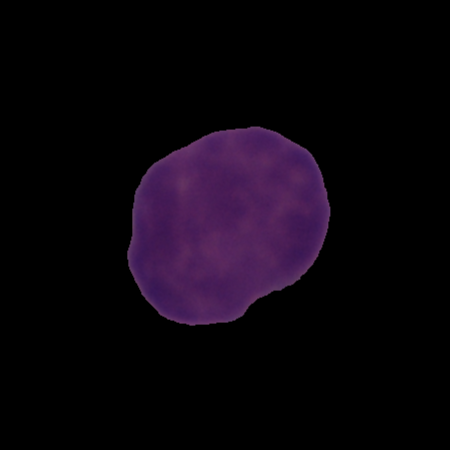

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from PIL import Image
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# نفس التعريف
ACCEPT, REVIEW, DEFER = 0, 1, 2

class DecisionNet(nn.Module):
    def __init__(self, num_classes=2, num_actions=3):
        super().__init__()
        backbone = models.resnet18(weights=None)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.cls_head = nn.Linear(feat_dim, num_classes)
        self.act_head = nn.Linear(feat_dim, num_actions)

    def forward(self, x):
        f = self.backbone(x)
        return self.cls_head(f), self.act_head(f)

MODEL_PATH = "/content/drive/MyDrive/hematology_project_outputs/decisionnet_resnet18_cnmctria_ge2.pt"
ckpt = torch.load(MODEL_PATH, map_location=device)

model2 = DecisionNet(num_classes=2, num_actions=3).to(device)
model2.load_state_dict(ckpt["model_state"])
model2.eval()

print("Loaded OK ✅")
print("class_names:", ckpt["class_names"], "img_size:", ckpt["img_size"])

# خذ صورة عشوائية من test_ds (الذي أنشأته سابقًا)
idx = random.choice(test_idx)  # من split indices الذي عندك
img_path, true_label = full_ds.samples[idx]
print("Sample path:", img_path)
print("True label idx:", true_label, "=>", full_ds.classes[true_label])

# افتح الصورة
img = Image.open(img_path).convert("RGB")
img


In [ ]:
from torchvision import transforms
import numpy as np

IMG_SIZE = ckpt["img_size"]

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

x = tfm(img).unsqueeze(0).to(device)

with torch.no_grad():
    cls_logits, act_logits = model2(x)
    cls_prob = F.softmax(cls_logits, dim=1).squeeze(0).cpu().numpy()
    act_prob = F.softmax(act_logits, dim=1).squeeze(0).cpu().numpy()

pred_idx = int(np.argmax(cls_prob))
pred_name = ckpt["class_names"][pred_idx]

p_accept, p_review, p_defer = act_prob.tolist()

print("Prediction:", pred_name, "| class probs:", cls_prob)
print("Action probs [A,R,D]:", act_prob)

# قرار بسيط للعرض (نفس منطق التطبيق)
t_review = 0.5
t_defer  = 0.7
if p_defer >= t_defer:
    decision = "DEFER"
elif p_review >= t_review:
    decision = "REVIEW"
else:
    decision = "ACCEPT"
print("Decision:", decision)


Prediction: blast | class probs: [0.9983267  0.00167325]
Action probs [A,R,D]: [9.9992239e-01 1.6475580e-05 6.1203056e-05]
Decision: ACCEPT


Class probs [blast, normal]: [0.9983267  0.00167325] => pred: blast
Action probs [A,R,D]: [9.9992239e-01 1.6475580e-05 6.1203056e-05] => pred: ACCEPT


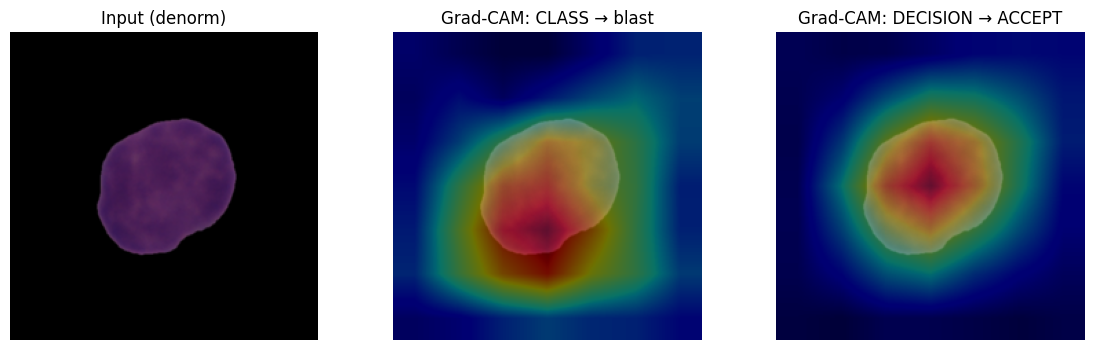

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ====== constants ======
ACTION_NAMES = {0: "ACCEPT", 1: "REVIEW", 2: "DEFER"}

# ====== helpers ======
def denorm_imagenet(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device)[:,None,None]
    std  = torch.tensor([0.229,0.224,0.225], device=t.device)[:,None,None]
    x = (t*std + mean).clamp(0,1)
    return x.permute(1,2,0).detach().cpu().numpy()

def overlay_cam(img_rgb01, cam01, alpha=0.45):
    heat = plt.cm.jet(cam01)[:,:,:3]
    out = (1-alpha)*img_rgb01 + alpha*heat
    return np.clip(out, 0, 1)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        def fwd_hook(module, inp, out):
            self.activations = out

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.h1 = target_layer.register_forward_hook(fwd_hook)
        self.h2 = target_layer.register_full_backward_hook(bwd_hook)

    def __call__(self, x, target_logit):
        self.model.zero_grad(set_to_none=True)
        cls_logits, act_logits = self.model(x)
        target_logit.backward(retain_graph=True)

        A  = self.activations   # [1,C,h,w]
        dA = self.gradients     # [1,C,h,w]

        w = dA.mean(dim=(2,3), keepdim=True)      # [1,C,1,1]
        cam = (w * A).sum(dim=1)                  # [1,h,w]
        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-9)

        cam = cam.unsqueeze(1)  # [1,1,h,w]
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return cam.squeeze().detach().cpu().numpy()

# ====== Grad-CAM setup ======
# آخر طبقة كونفلوشن في resnet18 backbone
target_layer = model2.backbone.layer4
cam_engine = GradCAM(model2, target_layer)

# ====== forward + CAM for both heads ======
model2.eval()
x = x.to(device)

with torch.enable_grad():
    x1 = x.clone().detach().requires_grad_(True)

    cls_logits, act_logits = model2(x1)

    cls_prob = F.softmax(cls_logits, dim=1).squeeze(0).detach().cpu().numpy()
    act_prob = F.softmax(act_logits, dim=1).squeeze(0).detach().cpu().numpy()

    pred_cls = int(cls_logits.argmax(dim=1).item())
    pred_act = int(act_logits.argmax(dim=1).item())

    print("Class probs [blast, normal]:", cls_prob, "=> pred:", ckpt["class_names"][pred_cls])
    print("Action probs [A,R,D]:", act_prob, "=> pred:", ACTION_NAMES[pred_act])

    # CAM for predicted class
    cam_cls = cam_engine(x1, cls_logits[0, pred_cls])

    # CAM for predicted decision
    cam_act = cam_engine(x1, act_logits[0, pred_act])

# ====== plot ======
img_vis = denorm_imagenet(x1[0].detach())
ov_cls = overlay_cam(img_vis, cam_cls, alpha=0.45)
ov_act = overlay_cam(img_vis, cam_act, alpha=0.45)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.imshow(img_vis); plt.axis("off"); plt.title("Input (denorm)")
plt.subplot(1,3,2); plt.imshow(ov_cls); plt.axis("off"); plt.title("Grad-CAM: CLASS → " + ckpt["class_names"][pred_cls])
plt.subplot(1,3,3); plt.imshow(ov_act); plt.axis("off"); plt.title("Grad-CAM: DECISION → " + ACTION_NAMES[pred_act])
plt.show()


In [ ]:
import os, math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ===== Decision names/thresholds (عدّل إذا تريد) =====
ACTION_NAMES = {0: "ACCEPT", 1: "REVIEW", 2: "DEFER"}
t_review = 0.5
t_defer  = 0.7

def action_from_probs(act_prob, t_review=0.5, t_defer=0.7):
    p_accept, p_review, p_defer = act_prob.tolist()
    if p_defer >= t_defer:
        return 2
    elif p_review >= t_review:
        return 1
    else:
        return 0

# ===== image helpers =====
def denorm_imagenet(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device)[:,None,None]
    std  = torch.tensor([0.229,0.224,0.225], device=t.device)[:,None,None]
    x = (t*std + mean).clamp(0,1)
    return x.permute(1,2,0).detach().cpu().numpy()

def overlay_cam(img_rgb01, cam01, alpha=0.45):
    heat = plt.cm.jet(cam01)[:,:,:3]
    out = (1-alpha)*img_rgb01 + alpha*heat
    return np.clip(out, 0, 1)

# ===== Grad-CAM engine =====
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        def fwd_hook(module, inp, out):
            self.activations = out

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.h1 = target_layer.register_forward_hook(fwd_hook)
        self.h2 = target_layer.register_full_backward_hook(bwd_hook)

    def __call__(self, x, target_logit):
        self.model.zero_grad(set_to_none=True)
        cls_logits, act_logits = self.model(x)
        target_logit.backward(retain_graph=True)

        A  = self.activations   # [1,C,h,w]
        dA = self.gradients     # [1,C,h,w]
        w = dA.mean(dim=(2,3), keepdim=True)      # [1,C,1,1]
        cam = (w * A).sum(dim=1)                  # [1,h,w]
        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-9)

        cam = cam.unsqueeze(1)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return cam.squeeze().detach().cpu().numpy()

# ===== explainability metrics =====
def binary_cell_mask_from_input(x_img_denorm, thr=0.06):
    """
    x_img_denorm: np [H,W,3] in [0,1], background غالباً أسود.
    يعيد mask للخلية (تقريب) بعتبة بسيطة.
    """
    g = x_img_denorm.mean(axis=2)  # grayscale
    mask = (g > thr).astype(np.uint8)
    return mask

def cam_metrics(cam01, cell_mask):
    """
    cam01: [H,W] in [0,1]
    cell_mask: [H,W] {0,1}
    """
    eps = 1e-9
    H, W = cam01.shape

    cam = cam01.astype(np.float32)
    p = cam / (cam.sum() + eps)  # probability map

    # 1) Entropy (lower = more focused)
    entropy = float(-(p * np.log(p + eps)).sum())

    # 2) Peakiness: max / mean داخل الخلية
    cell = cell_mask.astype(bool)
    if cell.sum() < 10:
        cell = np.ones_like(cell_mask, dtype=bool)  # fallback
    mean_cell = float(cam[cell].mean() + eps)
    peakiness = float(cam.max() / mean_cell)

    # 3) Focus ratio داخل الخلية مقابل خارجها
    sum_in = float(cam[cell].sum())
    sum_out = float(cam[~cell].sum())
    focus_in_ratio = float(sum_in / (sum_in + sum_out + eps))

    # 4) Center-of-mass distance from cell centroid (smaller = more centered)
    ys, xs = np.mgrid[0:H, 0:W]
    cy = float((p * ys).sum())
    cx = float((p * xs).sum())

    # cell centroid
    cy0 = float(ys[cell].mean())
    cx0 = float(xs[cell].mean())
    dist = float(np.sqrt((cy-cy0)**2 + (cx-cx0)**2) / np.sqrt(H*H + W*W))  # normalized

    return {
        "entropy": entropy,
        "peakiness": peakiness,
        "focus_in_ratio": focus_in_ratio,
        "com_dist_norm": dist
    }


In [ ]:
# ===== settings =====
MAX_SAMPLES = 800   # ارفعها لاحقاً (مثلاً 1600) إذا تريد كل test
SAVE_DIR = "/content/drive/MyDrive/hematology_project_outputs/explainability"
os.makedirs(SAVE_DIR, exist_ok=True)

model2.eval()
target_layer = model2.backbone.layer4
cam_engine = GradCAM(model2, target_layer)

rows = []
seen = 0

for batch in test_loader:
    # batch could be (x,y) or (x,y,paths). handle both
    if len(batch) == 2:
        xb, yb = batch
        paths = [None]*len(yb)
    else:
        xb, yb, paths = batch[0], batch[1], batch[2]

    for i in range(xb.size(0)):
        if seen >= MAX_SAMPLES:
            break

        x = xb[i:i+1].to(device)
        y = int(yb[i].item())
        path = paths[i] if paths is not None else None

        with torch.enable_grad():
            x1 = x.clone().detach().requires_grad_(True)
            cls_logits, act_logits = model2(x1)

            cls_prob = F.softmax(cls_logits, dim=1).squeeze(0).detach().cpu().numpy()
            act_prob = F.softmax(act_logits, dim=1).squeeze(0).detach().cpu().numpy()

            pred_cls = int(cls_logits.argmax(dim=1).item())
            pred_act = int(act_logits.argmax(dim=1).item())

            # قرار التطبيق بالـ thresholds (الأهم)
            app_act = action_from_probs(act_prob, t_review=t_review, t_defer=t_defer)

            # CAM للـ class و CAM للـ decision (حسب مخرج الرأس)
            cam_cls = cam_engine(x1, cls_logits[0, pred_cls])
            cam_dec = cam_engine(x1, act_logits[0, app_act])  # نستخدم قرار التطبيق

        # cell mask من الصورة (denorm)
        img_den = denorm_imagenet(x1[0].detach())
        cell_mask = binary_cell_mask_from_input(img_den, thr=0.06)

        m_cls = cam_metrics(cam_cls, cell_mask)
        m_dec = cam_metrics(cam_dec, cell_mask)

        rows.append({
            "path": path,
            "y_true": y,
            "y_pred": pred_cls,
            "p_blast": float(cls_prob[0]),
            "p_normal": float(cls_prob[1]),
            "act_accept": float(act_prob[0]),
            "act_review": float(act_prob[1]),
            "act_defer": float(act_prob[2]),
            "decision_app": app_act,  # 0 A, 1 R, 2 D

            # metrics (CLASS)
            "cls_entropy": m_cls["entropy"],
            "cls_peakiness": m_cls["peakiness"],
            "cls_focus_in": m_cls["focus_in_ratio"],
            "cls_com_dist": m_cls["com_dist_norm"],

            # metrics (DECISION)
            "dec_entropy": m_dec["entropy"],
            "dec_peakiness": m_dec["peakiness"],
            "dec_focus_in": m_dec["focus_in_ratio"],
            "dec_com_dist": m_dec["com_dist_norm"],
        })

        seen += 1

    if seen >= MAX_SAMPLES:
        break

df = pd.DataFrame(rows)
df["decision_name"] = df["decision_app"].map(ACTION_NAMES)
print("Saved samples:", len(df))
df.head()


Saved samples: 800


,path,y_true,y_pred,p_blast,p_normal,act_accept,act_review,act_defer,decision_app,cls_entropy,cls_peakiness,cls_focus_in,cls_com_dist,dec_entropy,dec_peakiness,dec_focus_in,dec_com_dist,decision_name
0,None,0,0,0.998896,0.001104,0.999934,0.000015,0.000051,0,10.522526,1.235995,0.287630,0.036281,10.426372,1.359322,0.337088,0.037870,ACCEPT
1,None,1,1,0.447594,0.552406,0.940337,0.056614,0.003048,0,10.046146,1.307362,0.345155,0.022456,10.704081,1.988394,0.127836,0.028005,ACCEPT
2,None,1,0,0.826536,0.173464,0.000013,0.999947,0.000039,1,10.682271,2.911627,0.108949,0.041319,10.325064,1.412237,0.425694,0.011316,REVIEW
3,None,0,0,0.978809,0.021191,0.998657,0.000460,0.000883,0,10.709058,2.087481,0.264285,0.063708,10.575540,1.526037,0.497640,0.041463,ACCEPT
4,None,1,0,0.993046,0.006954,0.999364,0.000361,0.000274,0,10.598370,1.258279,0.199603,0.045986,10.422689,1.392071,0.291932,0.021834,ACCEPT


In [ ]:
csv_path = os.path.join(SAVE_DIR, f"explainability_metrics_N{len(df)}.csv")
df.to_csv(csv_path, index=False)
print("✅ Saved CSV:", csv_path)

print("\nDecision distribution:")
print(df["decision_name"].value_counts(normalize=True))

print("\nMean metrics by decision (DECISION head):")
print(df.groupby("decision_name")[["dec_entropy","dec_peakiness","dec_focus_in","dec_com_dist"]].mean())


✅ Saved CSV: /content/drive/MyDrive/hematology_project_outputs/explainability/explainability_metrics_N800.csv

Decision distribution:
decision_name
ACCEPT    0.89
REVIEW    0.11
Name: proportion, dtype: float64

Mean metrics by decision (DECISION head):
               dec_entropy  dec_peakiness  dec_focus_in  dec_com_dist
decision_name                                                        
ACCEPT           10.518462       1.696590      0.382801      0.043428
REVIEW           10.406168       1.412469      0.341342      0.028775


In [ ]:
from scipy.stats import mannwhitneyu

acc = df[df["decision_app"]==0]
rev = df[df["decision_app"]==1]

def mw(name):
    a = acc[name].values
    r = rev[name].values
    if len(a) < 10 or len(r) < 10:
        return (np.nan, np.nan)
    stat, p = mannwhitneyu(a, r, alternative="two-sided")
    return stat, p

metrics = ["dec_entropy","dec_peakiness","dec_focus_in","dec_com_dist"]

print("ACCEPT N:", len(acc), "REVIEW N:", len(rev))
for m in metrics:
    stat, p = mw(m)
    print(f"{m:>12} | ACCEPT mean={acc[m].mean():.4f}  REVIEW mean={rev[m].mean():.4f}  | p={p:.3e}")


ACCEPT N: 712 REVIEW N: 88
 dec_entropy | ACCEPT mean=10.5185  REVIEW mean=10.4062  | p=3.556e-29
dec_peakiness | ACCEPT mean=1.6966  REVIEW mean=1.4125  | p=7.284e-14
dec_focus_in | ACCEPT mean=0.3828  REVIEW mean=0.3413  | p=8.487e-09
dec_com_dist | ACCEPT mean=0.0434  REVIEW mean=0.0288  | p=1.310e-15


/tmp/ipython-input-263846184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["ACCEPT","REVIEW"], showfliers=False)


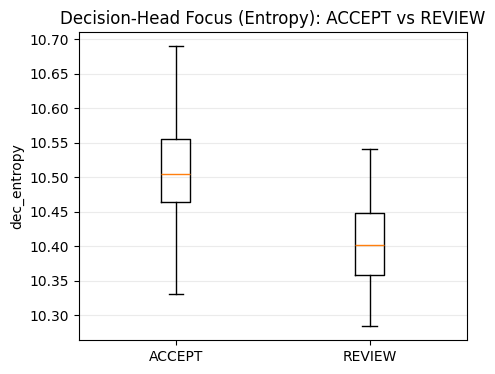

/tmp/ipython-input-263846184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["ACCEPT","REVIEW"], showfliers=False)


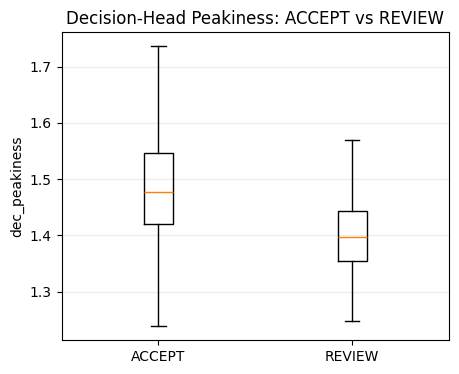

/tmp/ipython-input-263846184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["ACCEPT","REVIEW"], showfliers=False)


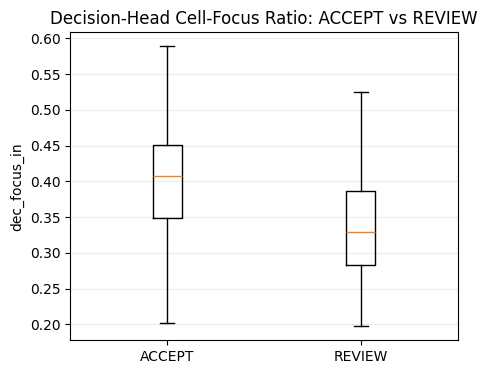

/tmp/ipython-input-263846184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["ACCEPT","REVIEW"], showfliers=False)


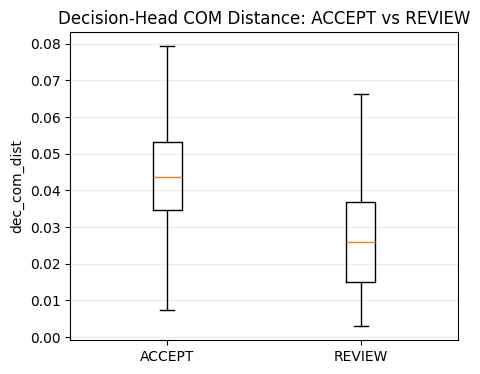

In [ ]:
def boxplot_metric(metric, title):
    data = [df[df["decision_app"]==0][metric].values, df[df["decision_app"]==1][metric].values]
    plt.figure(figsize=(5,4))
    plt.boxplot(data, labels=["ACCEPT","REVIEW"], showfliers=False)
    plt.title(title)
    plt.ylabel(metric)
    plt.grid(True, axis="y", alpha=0.25)
    plt.show()

boxplot_metric("dec_entropy",   "Decision-Head Focus (Entropy): ACCEPT vs REVIEW")
boxplot_metric("dec_peakiness", "Decision-Head Peakiness: ACCEPT vs REVIEW")
boxplot_metric("dec_focus_in",  "Decision-Head Cell-Focus Ratio: ACCEPT vs REVIEW")
boxplot_metric("dec_com_dist",  "Decision-Head COM Distance: ACCEPT vs REVIEW")


In [ ]:
# احفظ 6 صور من كل قرار (ACCEPT/REVIEW) لعرضها في الورقة
SAVE_EXAMPLES_PER_GROUP = 6

os.makedirs(os.path.join(SAVE_DIR, "overlays"), exist_ok=True)
savedA = 0
savedR = 0

model2.eval()

for batch in test_loader:
    xb, yb = batch[0], batch[1]
    for i in range(xb.size(0)):
        x = xb[i:i+1].to(device)
        y = int(yb[i].item())

        with torch.enable_grad():
            x1 = x.clone().detach().requires_grad_(True)
            cls_logits, act_logits = model2(x1)
            act_prob = F.softmax(act_logits, dim=1).squeeze(0).detach().cpu().numpy()
            app_act = action_from_probs(act_prob, t_review=t_review, t_defer=t_defer)

            if app_act == 0 and savedA >= SAVE_EXAMPLES_PER_GROUP:
                continue
            if app_act == 1 and savedR >= SAVE_EXAMPLES_PER_GROUP:
                continue
            if app_act not in [0,1]:
                continue

            pred_cls = int(cls_logits.argmax(dim=1).item())
            cam_cls = cam_engine(x1, cls_logits[0, pred_cls])
            cam_dec = cam_engine(x1, act_logits[0, app_act])

        img_den = denorm_imagenet(x1[0].detach())
        ov_cls = overlay_cam(img_den, cam_cls, alpha=0.45)
        ov_dec = overlay_cam(img_den, cam_dec, alpha=0.45)

        # save as png
        tag = "ACCEPT" if app_act==0 else "REVIEW"
        idx = savedA if app_act==0 else savedR

        plt.imsave(os.path.join(SAVE_DIR, "overlays", f"{tag}_{idx}_input.png"), img_den)
        plt.imsave(os.path.join(SAVE_DIR, "overlays", f"{tag}_{idx}_classcam.png"), ov_cls)
        plt.imsave(os.path.join(SAVE_DIR, "overlays", f"{tag}_{idx}_decisioncam.png"), ov_dec)

        if app_act==0: savedA += 1
        else: savedR += 1

        if savedA>=SAVE_EXAMPLES_PER_GROUP and savedR>=SAVE_EXAMPLES_PER_GROUP:
            break
    if savedA>=SAVE_EXAMPLES_PER_GROUP and savedR>=SAVE_EXAMPLES_PER_GROUP:
        break

print("✅ Saved overlays to:", os.path.join(SAVE_DIR, "overlays"))
print("Saved ACCEPT:", savedA, "Saved REVIEW:", savedR)


✅ Saved overlays to: /content/drive/MyDrive/hematology_project_outputs/explainability/overlays
Saved ACCEPT: 6 Saved REVIEW: 6


In [ ]:
# احفظ 6 صور من كل قرار (ACCEPT/REVIEW) لعرضها في الورقة
SAVE_EXAMPLES_PER_GROUP = 6

os.makedirs(os.path.join(SAVE_DIR, "overlays"), exist_ok=True)
savedA = 0
savedR = 0

model2.eval()

for batch in test_loader:
    xb, yb = batch[0], batch[1]
    for i in range(xb.size(0)):
        x = xb[i:i+1].to(device)
        y = int(yb[i].item())

        with torch.enable_grad():
            x1 = x.clone().detach().requires_grad_(True)
            cls_logits, act_logits = model2(x1)
            act_prob = F.softmax(act_logits, dim=1).squeeze(0).detach().cpu().numpy()
            app_act = action_from_probs(act_prob, t_review=t_review, t_defer=t_defer)

            if app_act == 0 and savedA >= SAVE_EXAMPLES_PER_GROUP:
                continue
            if app_act == 1 and savedR >= SAVE_EXAMPLES_PER_GROUP:
                continue
            if app_act not in [0,1]:
                continue

            pred_cls = int(cls_logits.argmax(dim=1).item())
            cam_cls = cam_engine(x1, cls_logits[0, pred_cls])
            cam_dec = cam_engine(x1, act_logits[0, app_act])

        img_den = denorm_imagenet(x1[0].detach())
        ov_cls = overlay_cam(img_den, cam_cls, alpha=0.45)
        ov_dec = overlay_cam(img_den, cam_dec, alpha=0.45)

        # save as png
        tag = "ACCEPT" if app_act==0 else "REVIEW"
        idx = savedA if app_act==0 else savedR

        plt.imsave(os.path.join(SAVE_DIR, "overlays", f"{tag}_{idx}_input.png"), img_den)
        plt.imsave(os.path.join(SAVE_DIR, "overlays", f"{tag}_{idx}_classcam.png"), ov_cls)
        plt.imsave(os.path.join(SAVE_DIR, "overlays", f"{tag}_{idx}_decisioncam.png"), ov_dec)

        if app_act==0: savedA += 1
        else: savedR += 1

        if savedA>=SAVE_EXAMPLES_PER_GROUP and savedR>=SAVE_EXAMPLES_PER_GROUP:
            break
    if savedA>=SAVE_EXAMPLES_PER_GROUP and savedR>=SAVE_EXAMPLES_PER_GROUP:
        break

print("✅ Saved overlays to:", os.path.join(SAVE_DIR, "overlays"))
print("Saved ACCEPT:", savedA, "Saved REVIEW:", savedR)


✅ Saved overlays to: /content/drive/MyDrive/hematology_project_outputs/explainability/overlays
Saved ACCEPT: 6 Saved REVIEW: 6


✅ Saved Fig.2 to: /content/drive/MyDrive/hematology_project_outputs/fig2_cnm_examples.png


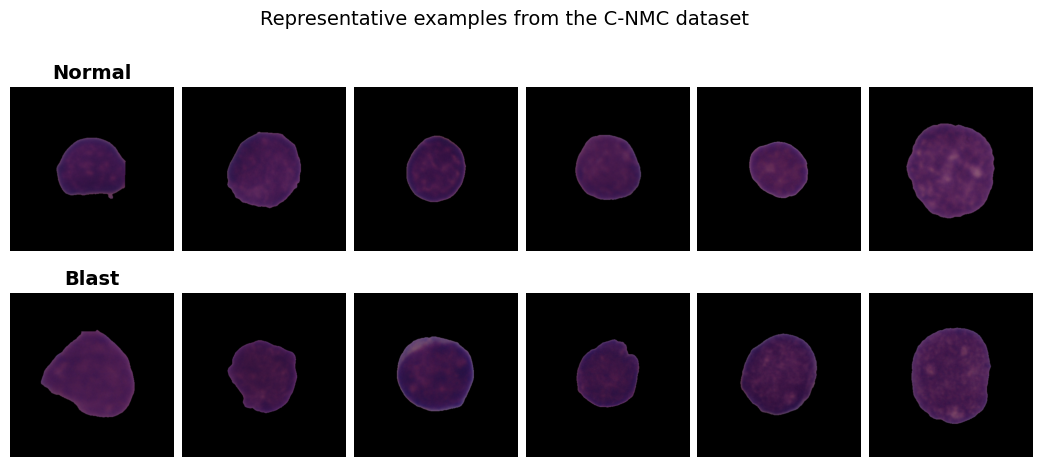

In [ ]:
import os, glob, random
import matplotlib.pyplot as plt
from PIL import Image

# ✅ مسار الداتا عندك
DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"
blast_dir  = os.path.join(DATA_DIR, "blast")
normal_dir = os.path.join(DATA_DIR, "normal")

blast_imgs  = glob.glob(os.path.join(blast_dir, "*.bmp"))
normal_imgs = glob.glob(os.path.join(normal_dir, "*.bmp"))

assert len(blast_imgs) > 0 and len(normal_imgs) > 0, "No images found! Check folders."

# ============
# إعداد الشكل
# ============
N = 6  # عدد الصور لكل فئة (غيره مثل 5 أو 8)
seed = 42
random.seed(seed)

blast_sel  = random.sample(blast_imgs,  N)
normal_sel = random.sample(normal_imgs, N)

fig, axes = plt.subplots(2, N, figsize=(2.2*N, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.15)

# صف normal
for i, p in enumerate(normal_sel):
    img = Image.open(p).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Normal", fontsize=14, fontweight="bold")

# صف blast
for i, p in enumerate(blast_sel):
    img = Image.open(p).convert("RGB")
    axes[1, i].imshow(img)
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Blast", fontsize=14, fontweight="bold")

# عنوان عام للشكل
fig.suptitle("Representative examples from the C-NMC dataset", fontsize=14, y=1.02)

# ✅ حفظ الشكل (اختياري)
out_path = "/content/drive/MyDrive/hematology_project_outputs/fig2_cnm_examples.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("✅ Saved Fig.2 to:", out_path)

plt.show()


✅ Saved Fig.3 to: /content/drive/MyDrive/hematology_project_outputs/explainability/fig3_gradcam_accept_review.png


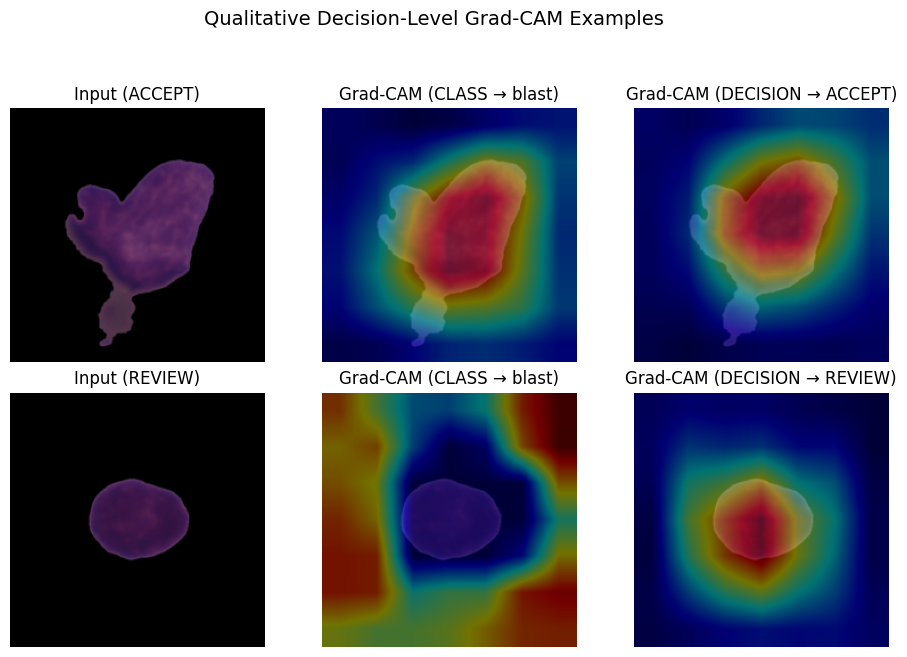


ACCEPT sample: /content/drive/MyDrive/C-NMC_training_data/blast/UID_45_23_10_all.bmp | action probs: [9.99860048e-01 2.56063868e-05 1.14267656e-04]
REVIEW sample: /content/drive/MyDrive/C-NMC_training_data/normal/UID_H24_33_4_hem.bmp | action probs: [0.09793565 0.899699   0.00236533]


In [ ]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms

# =========================
# 1) إعدادات ومسارات
# =========================
DATA_DIR = "/content/drive/MyDrive/C-NMC_training_data"
OUT_DIR  = "/content/drive/MyDrive/hematology_project_outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

ACTION_NAMES = {0:"ACCEPT", 1:"REVIEW", 2:"DEFER"}

IMG_SIZE = int(ckpt["img_size"]) if "img_size" in ckpt else 224

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# =========================
# 2) Grad-CAM Engine
#    (اختر آخر conv layer)
# =========================
# ResNet18: layer4 هو آخر بلوك
target_layer = model2.backbone.layer4

# إذا عندك GradCAM class سابقًا استخدمه:
# cam_engine = GradCAM(model2.backbone, target_layer)

# إذا ما موجود، استخدم هذا Grad-CAM خفيف:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.h1 = target_layer.register_forward_hook(self._forward_hook)
        self.h2 = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def __call__(self, x, target_logit):
        self.model.zero_grad(set_to_none=True)
        if x.grad is not None:
            x.grad.zero_()

        target_logit.backward(retain_graph=True)

        # [B,C,H,W]
        A = self.activations
        G = self.gradients

        weights = G.mean(dim=(2,3), keepdim=True)
        cam = (weights * A).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam.squeeze(0).squeeze(0).detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

cam_engine = GradCAM(model2.backbone, target_layer)

# =========================
# 3) أدوات عرض (إن لم تكن موجودة عندك)
# =========================
def denorm_imagenet(x_chw):
    """x_chw: Tensor [3,H,W] normalized -> returns numpy [H,W,3] in [0,1]"""
    mean = torch.tensor([0.485,0.456,0.406], device=x_chw.device)[:,None,None]
    std  = torch.tensor([0.229,0.224,0.225], device=x_chw.device)[:,None,None]
    x = x_chw * std + mean
    x = x.clamp(0,1)
    return x.permute(1,2,0).detach().cpu().numpy()

def overlay_cam(img_rgb01, cam01, alpha=0.45):
    """img_rgb01: [H,W,3] in [0,1], cam01: [h,w] in [0,1]"""
    import cv2
    H,W,_ = img_rgb01.shape
    cam_resized = cv2.resize(cam01, (W,H), interpolation=cv2.INTER_LINEAR)
    heat = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB) / 255.0
    out = (1-alpha)*img_rgb01 + alpha*heat
    out = np.clip(out, 0, 1)
    return out

# =========================
# 4) اختيار عينة ACCEPT وعينة REVIEW تلقائياً
# =========================
all_imgs = glob.glob(os.path.join(DATA_DIR, "blast", "*.bmp")) + \
           glob.glob(os.path.join(DATA_DIR, "normal", "*.bmp"))
random.shuffle(all_imgs)

def infer_one(path):
    img = Image.open(path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(device)
    x.requires_grad_(True)

    cls_logits, act_logits = model2(x)
    cls_prob = F.softmax(cls_logits, dim=1).squeeze(0).detach().cpu().numpy()
    act_prob = F.softmax(act_logits, dim=1).squeeze(0).detach().cpu().numpy()

    pred_cls = int(cls_logits.argmax(1).item())
    pred_act = int(act_logits.argmax(1).item())

    # CAM for class
    cam_cls = cam_engine(x, cls_logits[0, pred_cls])
    # CAM for decision
    cam_act = cam_engine(x, act_logits[0, pred_act])

    img_vis = denorm_imagenet(x[0].detach())
    ov_cls  = overlay_cam(img_vis, cam_cls, alpha=0.45)
    ov_act  = overlay_cam(img_vis, cam_act, alpha=0.45)

    return {
        "path": path,
        "img": img_vis,
        "ov_cls": ov_cls,
        "ov_act": ov_act,
        "pred_cls": ckpt["class_names"][pred_cls],
        "pred_act": ACTION_NAMES[pred_act],
        "act_prob": act_prob
    }

accept_sample = None
review_sample = None

for p in all_imgs:
    out = infer_one(p)
    if accept_sample is None and out["pred_act"] == "ACCEPT":
        accept_sample = out
    if review_sample is None and out["pred_act"] == "REVIEW":
        review_sample = out
    if accept_sample and review_sample:
        break

assert accept_sample is not None and review_sample is not None, "Couldn't find ACCEPT/REVIEW samples. Try increasing search."

# =========================
# 5) رسم Figure 3 (2×3)
# =========================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
plt.subplots_adjust(wspace=0.02, hspace=0.12)

# Row ACCEPT
axes[0,0].imshow(accept_sample["img"]);    axes[0,0].axis("off"); axes[0,0].set_title("Input (ACCEPT)")
axes[0,1].imshow(accept_sample["ov_cls"]); axes[0,1].axis("off"); axes[0,1].set_title(f"Grad-CAM (CLASS → {accept_sample['pred_cls']})")
axes[0,2].imshow(accept_sample["ov_act"]); axes[0,2].axis("off"); axes[0,2].set_title(f"Grad-CAM (DECISION → {accept_sample['pred_act']})")

# Row REVIEW
axes[1,0].imshow(review_sample["img"]);    axes[1,0].axis("off"); axes[1,0].set_title("Input (REVIEW)")
axes[1,1].imshow(review_sample["ov_cls"]); axes[1,1].axis("off"); axes[1,1].set_title(f"Grad-CAM (CLASS → {review_sample['pred_cls']})")
axes[1,2].imshow(review_sample["ov_act"]); axes[1,2].axis("off"); axes[1,2].set_title(f"Grad-CAM (DECISION → {review_sample['pred_act']})")

# عنوان صغير (اختياري)
fig.suptitle("Qualitative Decision-Level Grad-CAM Examples", y=1.02, fontsize=14)

save_path = os.path.join(OUT_DIR, "fig3_gradcam_accept_review.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("✅ Saved Fig.3 to:", save_path)
plt.show()

print("\nACCEPT sample:", accept_sample["path"], "| action probs:", accept_sample["act_prob"])
print("REVIEW sample:", review_sample["path"], "| action probs:", review_sample["act_prob"])


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def evaluate_decision_aware_model(
    model,
    dataloader,
    device="cuda"
):
    model.eval()

    total_samples = 0
    accepted_samples = 0
    correct_accepted = 0

    blast_total = 0
    blast_fn_accepted = 0

    defer_review_count = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            class_logits, decision_logits = model(images)

            class_probs = F.softmax(class_logits, dim=1)
            decision_probs = F.softmax(decision_logits, dim=1)

            class_preds = torch.argmax(class_probs, dim=1)
            decisions = torch.argmax(decision_probs, dim=1)

            total_samples += labels.size(0)

            # Accepted samples
            accept_mask = (decisions == 0)
            accepted_samples += accept_mask.sum().item()

            # Accuracy on ACCEPT only
            correct_accepted += (class_preds[accept_mask] == labels[accept_mask]).sum().item()

            # Blast FN (only for accepted blast cases)
            blast_mask = (labels == 1)
            blast_total += blast_mask.sum().item()

            blast_fn_accepted += (
                (blast_mask & accept_mask & (class_preds == 0))
            ).sum().item()

            # Review + Defer
            defer_review_count += (decisions != 0).sum().item()

    # Metrics
    coverage = 100.0 * accepted_samples / total_samples
    accepted_accuracy = (
        100.0 * correct_accepted / accepted_samples
        if accepted_samples > 0 else 0.0
    )

    blast_fn_rate = (
        100.0 * blast_fn_accepted / blast_total
        if blast_total > 0 else 0.0
    )

    deferral_rate = 100.0 * defer_review_count / total_samples

    return {
        "Coverage (%)": coverage,
        "Accepted Accuracy (%)": accepted_accuracy,
        "Blast FN Rate (%)": blast_fn_rate,
        "Deferral / Review (%)": deferral_rate
    }


In [ ]:
metrics = evaluate_decision_aware_model(
    model=model,
    dataloader=test_loader,
    device=device
)

for k, v in metrics.items():
    print(f"{k}: {v:.2f}")


Coverage (%): 89.31
Accepted Accuracy (%): 82.79
Blast FN Rate (%): 48.33
Deferral / Review (%): 10.69
